# Mini Project 2

*Date:* 04/04/2026

*Name:* Mikkel Korsgaard Sørensen

*Institution:* ES AAU

*Class:* NDS9

*Subject:* Numerical Scientific Computing

*Github Repo* https://github.com/NDS8-TCP/nsc-mikkel

*System specifications:*

- *CPU:* AMD Ryzen 7 PRO 6850U (16) @ 4.77 GHz

- *GPU:* AMD Radeon 680M [Integrated]

- *RAM:* 32 GiB LPDDR5 @ 6400 MT/s

- *OS*: Debian GNU/Linux forky/sid (forky) x86_64

## Lecture 4: Parallel Computing 1 — Peer Review MP1, Amdahl's Law & Multiprocessing

### ****Milestone 1:** Parallel Mandelbrot**

**Refactor to chunk-based Numba kernels**

In [9]:
# From slide 45 (The updated once)

# mandelbrot_parallel.py (Tasks 1-3 are one continuous script)
import numpy as np
from numba import njit
from multiprocessing import Pool
import time, os, statistics, matplotlib.pyplot as plt
from pathlib import Path

@njit
def mandelbrot_pixel(c_real, c_imag, max_iter):
    z_real = z_imag = 0.0
    for i in range(max_iter):
        zr2 = z_real*z_real
        zi2 = z_imag*z_imag
        if zr2 + zi2 > 4.0: return i
        z_imag = 2.0*z_real*z_imag + c_imag
        z_real = zr2 - zi2 + c_real
    return max_iter

@njit
def mandelbrot_chunk(row_start, row_end, N,
                     x_min, x_max, y_min, y_max, max_iter):
    out = np.empty((row_end - row_start, N), dtype=np.int32)
    dx = (x_max - x_min) / N
    dy = (y_max - y_min) / N
    for r in range(row_end - row_start):
        c_imag = y_min + (r + row_start) * dy
        for col in range(N):
            out[r, col] = mandelbrot_pixel(x_min + col*dx, c_imag, max_iter)
    return out

def mandelbrot_serial(N, x_min, x_max, y_min, y_max, max_iter=100):
    return mandelbrot_chunk(0, N, N, x_min, x_max, y_min, y_max, max_iter)

**Refactor your MP1 Numba code into three functions (two `@njit`, one plain wrapper):**

**`mandelbrot_pixel(c_real, c_imag, max_iter)` The scalar kernel you already have from L03. Returns the escape iteration count for a single complex point.**

**`mandelbrot_chunk(row_start, row_end, N, x_min, x_max, y_min, y_max, max_iter)` Loops over rows [row start, row end) and all columns. Computes pixel coordinates from index + bounds — no arrays received as input. Returns a (row end - row start)×N int32 array.**

**`mandelbrot_serial(N, x_min, ...) Thin wrapper: calls mandelbrot_chunk(0, N, ...)` — the whole grid as one chunk.**

I am a bit unsure as to what exact *L03 output* is. I assume that it is the numba compiled version.

In [10]:
from numba import njit
import numpy as np
# Copied from lecture 3

@njit                       # <-- entire function compiled !
def mandelbrot_naive_numba(xmin, xmax, ymin, ymax, width, height, max_iter=100):
    """Fully JIT - compiled Mandelbrot --- structure identical to naive."""
    x = np.linspace(xmin, xmax, width)
    y = np.linspace(ymin, ymax, height)
    result = np.zeros((height, width), dtype=np.int32)

    for i in range(height):             # compiled loop
        for j in range(width):          # compiled loop
            c = x[j] + 1j * y[i]
            z = 0j                      # complex literal: type inference works!
            n = 0
            while n < max_iter and (z.real*z.real + z.imag*z.imag) <= 4.0:
                z = z*z + c
                n += 1
            result[i, j] = n
    return result

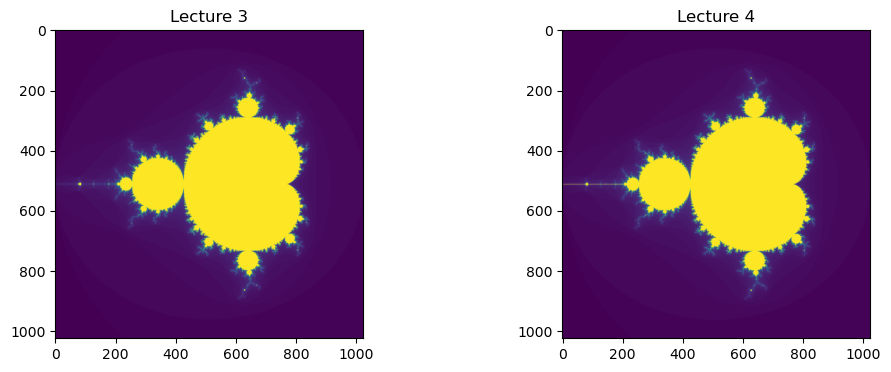

In [11]:
mandelbrot_naive_numba(-2, 1, -1.5, 1.5, 1024, 1024, 100)
l03_image = mandelbrot_naive_numba(-2, 1, -1.5, 1.5, 1024, 1024, 100)
l04_image = mandelbrot_serial(1024, -2, 1, -1.5, 1.5, 100)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(l03_image)
axes[0].set_title("Lecture 3")
axes[1].imshow(l04_image)
axes[1].set_title("Lecture 4")
plt.show()

They look the same.

****Done?** Serial result matches your L03 output → commit**

```sh
┌──(mikkel@pella)-[~/Sync/AAU/Semester 8/github/nsc-mikkel]
└─$ git log -n 1
commit 462cfa1b608b71de84442488d75ecdb95192a29e (HEAD -> main)
Author: mikkel-coder <mikkel.ks.sorensen@gmail.com>
Date:   Fri Mar 6 13:21:19 2026 +0000

    l04: milestone 1 done
```

### ****Milestone 2:** Parallel Mandelbrot**

**Implement Pool.map wrapper; verify result**

In [12]:
# From slide 47

# --- MP2 M2: add below M1 in mandelbrot_parallel.py ---
def _worker(args):
    return mandelbrot_chunk(*args)

def mandelbrot_parallel(N, x_min, x_max, y_min, y_max,
                        max_iter=100, n_workers=4):
    chunk_size = max(1, N // n_workers)
    chunks, row = [], 0
    while row < N:
        row_end = min(row + chunk_size, N)
        chunks.append((row, row_end, N, x_min, x_max, y_min, y_max, max_iter))
        row = row_end

    with Pool(processes=n_workers) as pool:
        pool.map(_worker, chunks)       # un-timed warm-up: Numba JIT in workers
        parts = pool.map(_worker, chunks)
    return np.vstack(parts)

if __name__ == '__main__':
    result = mandelbrot_parallel(1024, -2.5, 1.0, -1.25, 1.25, n_workers=4)

- ****Write** `mandelbrot_parallel(N, x_min, x_max, y_min, y_max, max_iter, n_workers)`**
    - **Build a list of chunk tuples: (rows_tart, row_end, N, x_min, x_max, y_min, y_max, max_iter)**
    - **Use `pool.map(_worker, chunks)` to distribute across workers**
    - **Reassemble with `np.vstack(parts)`**

Already done. Please see the code above.

- ****Pass only parameters — not a pre-computed grid****
    - **In MP1 we pre-created the full complex grid `C` and passed it to the iteration algorithm — passing a slice of that array to each worker would mean sending ∼8 KB per task over IPC**
    - **Instead: pass only scalar bounds `(x_min, x_max, y_min, y_max, N)` and let each worker compute its own coordinates**
    - **IPC input per task: ∼60 bytes (8 scalars) vs. ∼8 KB (1024-element float64 array)**
    - **IPC output per task is unavoidable: chunk size × N × 4 bytes (the result array)**

Already done. Please see the code above.

- ****Wrapper function** `_worker(args)`**
    - **`pool.map` calls `func(item)` — it takes only one argument**
    - **`mandelbrot_chunk` takes 8 arguments, so `_worker` receives the packed tuple and unpacks it**
    - **Normally, this can be done with a lambda function, but lambdas are not picklable, so it must be defined as function at module level.**

Already done. Please see the code above.

****Done?** Verify result matches serial → commit**

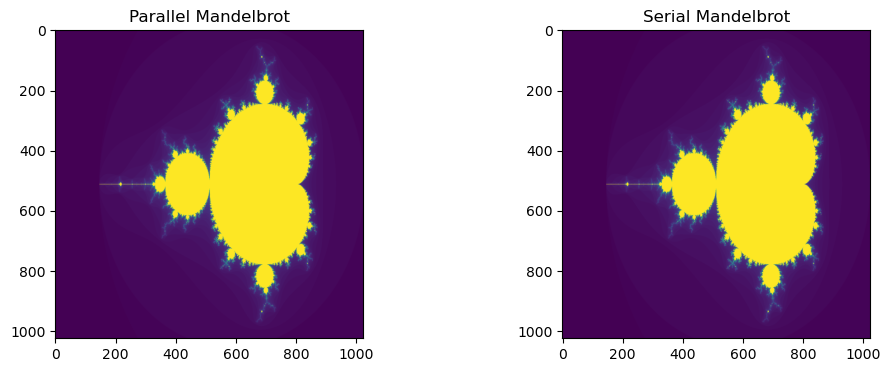

In [13]:
result_serial = mandelbrot_serial(1024, -2.5, 1.0, -1.25, 1.25)
# Note that the x_min has changed in the slides.
# That is why the imamge looks a bit squeezed

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(result)
axes[0].set_title("Parallel Mandelbrot")
axes[1].imshow(result_serial)
axes[1].set_title("Serial Mandelbrot")
plt.show()

They look the same. We are all good.

```sh
┌──(mikkel@pella)-[~/Sync/AAU/Semester 8/github/nsc-mikkel]
└─$ git log -n 1
commit 26184378749da1d2f87a7f3806dc9a3e64851ce4 (HEAD -> main)
Author: mikkel-coder <mikkel.ks.sorensen@gmail.com>
Date:   Fri Mar 6 13:40:19 2026 +0000

    l04: milestone 2 done
```

### ****Milestone 3:** Parallel Mandelbrot**

**Benchmark sweep; speedup and efficiency table**

****Serial baseline:** call mandelbrot serial 3 times after your M1 warm-up (Numba already compiled in main process); take median**

- **Where to place the timer:**
    - **Start `t0` immediately before `pool.map()`**
    - **Stop immediately after `np.vstack(parts)` — include assembly time**
    - **Keep Pool creation *outside* the timed region**

In [14]:
def m3_compute():
    times = []
    speedups = []
    efficiencies = []

    # From slide 49, with saving results implemented by me

    # --- MP2 M3: benchmark (in __main__ block) ---
    N, max_iter = 1024, 100
    X_MIN, X_MAX, Y_MIN, Y_MAX = -2.5, 1.0, -1.25, 1.25

    # Serial baseline (Numba already warm after M1 warm-up)
    all_times = []
    for _ in range(3):
        t0 = time.perf_counter()
        mandelbrot_serial(N, X_MIN, X_MAX, Y_MIN, Y_MAX, max_iter)
        times.append(time.perf_counter() - t0)
    t_serial = statistics.median(times)

    for n_workers in range(1, os.cpu_count() + 1):
        chunk_size = max(1, N // n_workers)
        chunks, row = [], 0
        while row < N:
            end = min(row + chunk_size, N)
            chunks.append((row, end, N, X_MIN, X_MAX, Y_MIN, Y_MAX, max_iter))
            row = end
        with Pool(processes=n_workers) as pool:
            pool.map(_worker, chunks)           # warm-up: Numba JIT in all workers
            times = []
            for _ in range(3):
                t0 = time.perf_counter()
                np.vstack(pool.map(_worker, chunks))
                times.append(time.perf_counter() - t0)
        t_par = statistics.median(times)
        speedup = t_serial / t_par
        print(f"{n_workers:2d} workers: {t_par:.3f}s, speedup={speedup:.2f}x, eff={speedup/n_workers*100:.0f}%")

        # Added by me
        all_times.append(t_par)
        speedups.append(speedup)
        efficiencies.append(speedup/n_workers)

    return all_times, speedups, efficiencies

In [15]:
from pathlib import Path
import pandas as pd

m3_file = Path("l04_milestone3.csv")

if not m3_file.exists():
    m3_times, m3_speedups, m3_efficiencies = m3_compute()
    workers = list(range(1, os.cpu_count() + 1))
    df = pd.DataFrame({
        "workers": workers,
        "time": m3_times,
        "speedup": m3_speedups,
        "efficiency": m3_efficiencies
    })
    df.to_csv(m3_file, index_label=False)

 1 workers: 0.055s, speedup=0.85x, eff=85%
 2 workers: 0.029s, speedup=1.61x, eff=81%
 3 workers: 0.036s, speedup=1.31x, eff=44%
 4 workers: 0.026s, speedup=1.82x, eff=46%
 5 workers: 0.026s, speedup=1.83x, eff=37%
 6 workers: 0.020s, speedup=2.28x, eff=38%
 7 workers: 0.020s, speedup=2.33x, eff=33%
 8 workers: 0.017s, speedup=2.80x, eff=35%
 9 workers: 0.017s, speedup=2.83x, eff=31%
10 workers: 0.015s, speedup=3.11x, eff=31%
11 workers: 0.014s, speedup=3.28x, eff=30%
12 workers: 0.013s, speedup=3.57x, eff=30%
13 workers: 0.012s, speedup=3.80x, eff=29%
14 workers: 0.012s, speedup=3.80x, eff=27%
15 workers: 0.011s, speedup=4.12x, eff=27%
16 workers: 0.011s, speedup=4.27x, eff=27%


**Sweep `n_workers` from `1` to `os.cpu_count()`; for each worker count:**

**1. Create a fresh `Pool(processes=n_workers)`**

Already done. Please see the code above.

**2. Run one **un-timed** `pool.map(_worker, chunks)` — this triggers Numba JIT compilation in every worker process; without this, JIT time is included in your measurement**

Already done. Please see the code above.

**3. Run 3 **timed** `pool.map` calls; take `statistics.median()`**

Already done. Please see the code above.

**4. Record: time, speedup $S_p = t_{serial}/t_p$, efficiency $E_p = S_p/p$**

Already done. Please see the code above.

****Done?** Record speedup table in performance notebook (MP2) → commit**

In [16]:
from IPython.display import display
m3_results = pd.read_csv(m3_file)

# Nicely formatted
display(
    m3_results.style
    .hide(axis="index")
    .format({
            "time": "{:.3f}s",
            "speedup": "{:.2f}x",
            "efficiency": "{:.1%}"
            })
    .background_gradient()
)

workers,time,speedup,efficiency
1,0.055s,0.85x,84.9%
2,0.029s,1.61x,80.5%
3,0.036s,1.31x,43.5%
4,0.026s,1.82x,45.6%
5,0.026s,1.83x,36.6%
6,0.020s,2.28x,38.1%
7,0.020s,2.33x,33.4%
8,0.017s,2.80x,35.0%
9,0.017s,2.83x,31.4%
10,0.015s,3.11x,31.1%


In [21]:
from IPython.display import Markdown, display
import pandas as pd

m3_results = pd.read_csv(m3_file)

# Copy data, but only for (nice looking) displaying (in markdown)
# note that .map changes the value, while .style does not
# AI-assisted
df_display = m3_results.copy()
df_display["workers"] = df_display["workers"].map("{:>2}".format)
df_display["time"] = df_display["time"].map("{:>.3f}s".format)
df_display["speedup"] = df_display["speedup"].map("{:>.2f}x".format)
df_display["efficiency"] = df_display["efficiency"].map("{:>.1%}".format)

display(Markdown(df_display.to_markdown(index=False)))

|   workers | time   | speedup   | efficiency   |
|----------:|:-------|:----------|:-------------|
|         1 | 0.055s | 0.85x     | 84.9%        |
|         2 | 0.029s | 1.61x     | 80.5%        |
|         3 | 0.036s | 1.31x     | 43.5%        |
|         4 | 0.026s | 1.82x     | 45.6%        |
|         5 | 0.026s | 1.83x     | 36.6%        |
|         6 | 0.020s | 2.28x     | 38.1%        |
|         7 | 0.020s | 2.33x     | 33.4%        |
|         8 | 0.017s | 2.80x     | 35.0%        |
|         9 | 0.017s | 2.83x     | 31.4%        |
|        10 | 0.015s | 3.11x     | 31.1%        |
|        11 | 0.014s | 3.28x     | 29.9%        |
|        12 | 0.013s | 3.57x     | 29.8%        |
|        13 | 0.012s | 3.80x     | 29.2%        |
|        14 | 0.012s | 3.80x     | 27.1%        |
|        15 | 0.011s | 4.12x     | 27.5%        |
|        16 | 0.011s | 4.27x     | 26.7%        |

I suspect that `Pool.map()`'s internal overhead results in a slowdown and efficiency lose for 1 worker. We can also see that mandelbrot "overhead" from the stacking results in SMT improving speedup.

```sh
┌──(mikkel@pella)-[~/Sync/AAU/Semester 8/github/nsc-mikkel]
└─$ git log -n 1
commit 8f0edf54653ee7e33a7149931dea81b6e631a549 (HEAD -> main)
Author: mikkel-coder <mikkel.ks.sorensen@gmail.com>
Date:   Sun Mar 8 18:45:31 2026 +0000

    l04: milestone 3 done
```

## Lecture 5: Parallel Computing 2 — Granularity, Load Balancing & Map-Filter-Reduce

### ****Milestone 1:** Chunked Mandelbrot (20 min)**

****Goal:** Decouple the number of chunks from the number of workers.**

In [11]:
from numba import njit

# From slide 27, with the implementation filled in by me
# based on lecture 4.

# From L04 (unchanged — add `cache=True`` if not already there):
@njit(cache=True)
def mandelbrot_pixel(c_real, c_imag, max_iter):
    z_real = z_imag = 0.0
    for i in range(max_iter):
        zr2 = z_real*z_real
        zi2 = z_imag*z_imag
        if zr2 + zi2 > 4.0: return i
        z_imag = 2.0*z_real*z_imag + c_imag
        z_real = zr2 - zi2 + c_real
    return max_iter

@njit(cache=True)
def mandelbrot_chunk(row_start, row_end, N, x_min, x_max, y_min, y_max, max_iter):
    out = np.empty((row_end - row_start, N), dtype=np.int32)
    dx = (x_max - x_min) / N
    dy = (y_max - y_min) / N
    for r in range(row_end - row_start):
        c_imag = y_min + (r + row_start) * dy
        for col in range(N):
            out[r, col] = mandelbrot_pixel(x_min + col*dx, c_imag, max_iter)
    return out

def _worker(args): 
    return mandelbrot_chunk(*args) # plain Python, must be module-level

In [12]:
# From slide 27

# Extend your L04 mandelbrot parallel to (include n chunks):
def mandelbrot_parallel(N, x_min, x_max, y_min, y_max,
                        max_iter=100, n_workers=4, n_chunks=None):
    if n_chunks is None:
        n_chunks = n_workers
    chunk_size = max(1, N // n_chunks)
    chunks, row = [], 0
    while row < N:
        row_end = min(row + chunk_size, N)
        chunks.append((row, row_end, N, x_min, x_max, y_min, y_max, max_iter))
        row = row_end
    tiny = [(0, 8, 8, x_min, x_max, y_min, y_max, max_iter)]
    with Pool(processes=n_workers) as pool:
        pool.map(_worker, tiny)         # warm-up: load JIT cache in workers
        parts = pool.map(_worker, chunks)
    return np.vstack(parts)

****What to do:****

- **Add an `n_chunks` parameter to `mandelbrot_parallel` (default: `n_chunks = n_workers`)**

Done. Please see the code above.

- **Verify output still matches the serial result from L04**

In [13]:
# This is a copy from lecture 4, but with updated function names


# From slide 45 (The updated once)

# mandelbrot_parallel.py (Tasks 1-3 are one continuous script)
import numpy as np
from numba import njit
from multiprocessing import Pool
import time, os, statistics, matplotlib.pyplot as plt
from pathlib import Path

@njit
def mandelbrot_pixel_l04(c_real, c_imag, max_iter):
    z_real = z_imag = 0.0
    for i in range(max_iter):
        zr2 = z_real*z_real
        zi2 = z_imag*z_imag
        if zr2 + zi2 > 4.0: return i
        z_imag = 2.0*z_real*z_imag + c_imag
        z_real = zr2 - zi2 + c_real
    return max_iter

@njit
def mandelbrot_chunk_l04(row_start, row_end, N,
                     x_min, x_max, y_min, y_max, max_iter):
    out = np.empty((row_end - row_start, N), dtype=np.int32)
    dx = (x_max - x_min) / N
    dy = (y_max - y_min) / N
    for r in range(row_end - row_start):
        c_imag = y_min + (r + row_start) * dy
        for col in range(N):
            out[r, col] = mandelbrot_pixel_l04(x_min + col*dx, c_imag, max_iter)
    return out

def mandelbrot_serial_l04(N, x_min, x_max, y_min, y_max, max_iter=100):
    return mandelbrot_chunk_l04(0, N, N, x_min, x_max, y_min, y_max, max_iter)

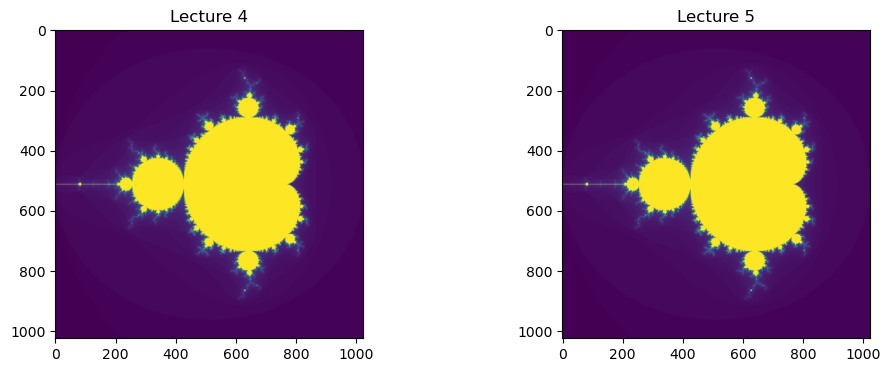

In [14]:
l04_image = mandelbrot_serial_l04(1024, -2, 1, -1.5, 1.5, 100)
l05_image = mandelbrot_parallel(1024, -2, 1, -1.5, 1.5, 100, n_workers=os.cpu_count()//2)


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(l04_image)
axes[0].set_title("Lecture 4")
axes[1].imshow(l05_image)
axes[1].set_title("Lecture 5")
plt.show()

They appear the same.

- **Re-run the L04 worker-count benchmark with `n_chunks = 4 × n_workers`; note any change**

Note that there is no `n_chunks` in lecture 4.

In [15]:
!cat l04_exercises.ipynb | grep -i "n_chunks"

I therefore assume that I am asked to compare with the benchmark from milestone 3 in lecture 4.

In [16]:
# Copy from lecture 4, milestone 3 - adaptive with new function names + n_chunks

def compute_l04(compare: bool):
    # From slide 49

    # --- MP2 M3: benchmark (in __main__ block) ---
    N, max_iter = 1024, 100
    X_MIN, X_MAX, Y_MIN, Y_MAX = -2.5, 1.0, -1.25, 1.25

    # Serial baseline (Numba already warm after M1 warm-up)
    times = []
    for _ in range(3):
        t0 = time.perf_counter()
        mandelbrot_serial_l04(N, X_MIN, X_MAX, Y_MIN, Y_MAX, max_iter)
        times.append(time.perf_counter() - t0)
    t_serial = statistics.median(times)

    for n_workers in range(1, os.cpu_count() + 1):
        if compare:
            chunk_size = max(1, N // (4 * n_workers))
        else:
            chunk_size = max(1, N // n_workers)
        chunks, row = [], 0
        while row < N:
            end = min(row + chunk_size, N)
            chunks.append((row, end, N, X_MIN, X_MAX, Y_MIN, Y_MAX, max_iter))
            row = end

        # Assert added by me
        if compare:
            n_chunks = 4 * n_workers
            # there may be more chunks needed to include trailing rows
            assert n_chunks <= len(chunks)

        with Pool(processes=n_workers) as pool:
            pool.map(_worker, chunks)           # warm-up: Numba JIT in all workers
            times = []
            for _ in range(3):
                t0 = time.perf_counter()
                np.vstack(pool.map(_worker, chunks))
                times.append(time.perf_counter() - t0)
        t_par = statistics.median(times)
        speedup = t_serial / t_par
        # Added by me: include print og chunks
        print(f"{n_workers:2d} workers: {t_par:.3f}s, speedup={speedup:.2f}x, eff={speedup/n_workers*100:.0f}%, n_chunks={len(chunks)}")


In [17]:
compute_l04(False) # n_chunks ≈ n_workers (Default)

 1 workers: 0.061s, speedup=1.15x, eff=115%, n_chunks=1
 2 workers: 0.034s, speedup=2.09x, eff=105%, n_chunks=2
 3 workers: 0.036s, speedup=1.93x, eff=64%, n_chunks=4
 4 workers: 0.030s, speedup=2.36x, eff=59%, n_chunks=4
 5 workers: 0.027s, speedup=2.57x, eff=51%, n_chunks=6
 6 workers: 0.021s, speedup=3.31x, eff=55%, n_chunks=7
 7 workers: 0.022s, speedup=3.24x, eff=46%, n_chunks=8
 8 workers: 0.018s, speedup=3.95x, eff=49%, n_chunks=8
 9 workers: 0.016s, speedup=4.29x, eff=48%, n_chunks=10
10 workers: 0.016s, speedup=4.48x, eff=45%, n_chunks=11
11 workers: 0.014s, speedup=4.87x, eff=44%, n_chunks=12
12 workers: 0.014s, speedup=5.15x, eff=43%, n_chunks=13
13 workers: 0.012s, speedup=5.73x, eff=44%, n_chunks=14
14 workers: 0.013s, speedup=5.59x, eff=40%, n_chunks=15
15 workers: 0.014s, speedup=4.98x, eff=33%, n_chunks=16
16 workers: 0.013s, speedup=5.44x, eff=34%, n_chunks=16


In [18]:
compute_l04(True) # n_chunks ≈ 4 * n_workers

 1 workers: 0.059s, speedup=1.18x, eff=118%, n_chunks=4
 2 workers: 0.031s, speedup=2.21x, eff=111%, n_chunks=8
 3 workers: 0.023s, speedup=3.03x, eff=101%, n_chunks=13
 4 workers: 0.019s, speedup=3.57x, eff=89%, n_chunks=16
 5 workers: 0.017s, speedup=4.07x, eff=81%, n_chunks=21
 6 workers: 0.016s, speedup=4.43x, eff=74%, n_chunks=25
 7 workers: 0.013s, speedup=5.16x, eff=74%, n_chunks=29
 8 workers: 0.014s, speedup=5.12x, eff=64%, n_chunks=32
 9 workers: 0.014s, speedup=4.92x, eff=55%, n_chunks=37
10 workers: 0.013s, speedup=5.50x, eff=55%, n_chunks=41
11 workers: 0.011s, speedup=6.09x, eff=55%, n_chunks=45
12 workers: 0.013s, speedup=5.33x, eff=44%, n_chunks=49
13 workers: 0.011s, speedup=6.36x, eff=49%, n_chunks=54
14 workers: 0.011s, speedup=6.17x, eff=44%, n_chunks=57
15 workers: 0.012s, speedup=5.56x, eff=37%, n_chunks=61
16 workers: 0.012s, speedup=5.92x, eff=37%, n_chunks=64


I terms of runtime, there is effectively no differences. In theory, one would expect the runtime to increase due to extra scheduling overhead.

****Done?** Verify result matches serial output → commit**

```sh
┌──(mikkel@pella)-[~/Sync/AAU/Semester 8/github/nsc-mikkel]
└─$ git log -n 1
commit d7bcbf791bc6e55289bf48742a4eedc920caa430 (HEAD -> main)
Author: mikkel-coder <mikkel.ks.sorensen@gmail.com>
Date:   Sun Mar 15 16:42:25 2026 +0000

    l05: milestone 1 done
```

### ****Milestone 2:** Optimal Chunk Size (15 min)**

****Fix `n_workers` at your L04 optimum. Sweep `n_chunks`, measure wall time, and compute LIF = $ p \cdot T_p/T_1 − 1 $.****

****Suggested configurations (`n_workers` = your best):****

| **n_chunks** | **time (s)** | **vs. 1×** | **LIF** |
| -------------- | ------------ | ---------- | ------- |
| 1× n_workers   | —            | baseline   | —       |
| 2× n_workers   | —            | —          | —       |
| 4× n_workers   | —            | —          | —       |
| 8× n_workers   | —            | —          | —       |
| 16× n_workers  | —            | —          | —       |

****Tips:****

- **Use `statistics.median()` of 3+ runs**

- **Include warm-up before timing**

- **LIF minimum = sweet spot**

- **Typical sweet spot: 4–8× `n_workers`**

I am unsure what "optimum" is. I assume that it refers to speedup.

Looking at my own lecture 4 milestone 3, the highest speedup was achieved using `n_workers=16`

*NOTE:* That the denominator in the LIF formula can be either $\sum{t_i}$ (sum of all chunk runtimes) or $T_1$ (measured serial wall time). Since we are given the formula in this exercise with $T_1$ I have chosen to use that. 

In [19]:
import statistics


def compute_mp2():
    n_workers = 16
    n_chunks = [2**i * n_workers for i in range(5)]

    all_times = []
    speedups = []
    lifs = []

    # warmup
    mandelbrot_parallel(1024, -2, 1, -1.5, 1.5, 100, n_workers, 16)

    for chunk in n_chunks:
        times = []
        for _ in range(3):
            # Using this lectures (l05) parallel mandelbrot
            t0 = time.perf_counter()
            mandelbrot_parallel(1024, -2, 1, -1.5, 1.5, 100, n_workers, chunk)
            times.append(time.perf_counter() - t0)
            
        t_par = statistics.median(times)
        all_times.append(t_par)
        speedups.append(all_times[0]/t_par)
        lifs.append(n_workers * t_par / all_times[0] - 1)
    
    return n_chunks, all_times, speedups, lifs

In [20]:
from pathlib import Path
import pandas as pd

m2_file = Path("l05_milestone2.csv")

if not m2_file.exists():
    n_chunks, times, speedups, lifs = compute_mp2()
    df = pd.DataFrame({
        "n_chunks": n_chunks,
        "time": times,
        "speedup": speedups,
        "lif": lifs
    })
    df.to_csv(m2_file, index_label=False)

Print the table using both pandas and markdown for pdf.

In [21]:
m2_results = pd.read_csv(m2_file)

display(
    m2_results.style
    .hide(axis="index")
    .format({
            "time": "{:.3f}s",
            "speedup": "{:.2f}x",
            "lif": "{:.2f}"
            })
)

n_chunks,time,speedup,lif
16,0.238s,1.00x,15.00
32,0.243s,0.98x,15.33
64,0.240s,0.99x,15.13
128,0.237s,1.01x,14.91
256,0.238s,1.00x,15.00


In [22]:
from IPython.display import Markdown, display
import pandas as pd

m2_results = pd.read_csv(m2_file)

df_display = m2_results.copy()
df_display["n_chunks"] = df_display["n_chunks"].map("{:>2}".format)
df_display["time"] = df_display["time"].map("{:>.3f}s".format)
df_display["speedup"] = df_display["speedup"].map("{:>.2f}x".format)
df_display["lif"] = df_display["lif"].map("{:>.2f}".format)

display(Markdown(df_display.to_markdown(index=False)))

|   n_chunks | time   | speedup   |   lif |
|-----------:|:-------|:----------|------:|
|         16 | 0.238s | 1.00x     | 15    |
|         32 | 0.243s | 0.98x     | 15.33 |
|         64 | 0.240s | 0.99x     | 15.13 |
|        128 | 0.237s | 1.01x     | 14.91 |
|        256 | 0.238s | 1.00x     | 15    |

****Done?** Record optimal `n_chunks` and LIF in performance notebook (MP2) → commit**

In [23]:
m2_results = pd.read_csv(m2_file)

# Find the "sweet spot"
row_idx = m2_results["lif"].idxmin()
optimal_n_chunks = m2_results.iloc[row_idx]["n_chunks"]
optimal_lif = m2_results.iloc[row_idx]["lif"]

print(f"Optimal Number of chunks: {optimal_n_chunks:.0f}")
print(f"Optimal LIF: {optimal_lif:.2f}") # "sweet spot"

Optimal Number of chunks: 128
Optimal LIF: 14.91


```sh
┌──(mikkel@pella)-[~/Sync/AAU/Semester 8/github/nsc-mikkel]
└─$ git log -n 1
commit e5a9bc6e7feb7409accc19e2fbe290a13ffd1b84 (HEAD -> main)
Author: mikkel-coder <mikkel.ks.sorensen@gmail.com>
Date:   Sun Mar 15 18:25:46 2026 +0000

    l05: milestone 2 done
```

### ****Milestone 3:** Comprehensive Analysis (20 min)**

****Create a full performance comparison at $1024×1024$, `max_iter=100`:****

#### ****1 Speedup table:****

| **Implementation** | **Time (s)** | **Speedup** |
| ------------------ | ------------ | ----------- |
| Naive Python       | —            | 1x          |
| Numpy              | —            | —           |
| Numba (@njit)      | —            | —           |
| Parallel (opt.)    | —            | —           |

I assume that the parallel implementation refers to the implementation from milestone 1. *Note*: I am using my optimal number of workers and chunk size from milestone 2.

In [24]:
# warmup
mandelbrot_parallel(1024, -2, 1, -1.5, 1.5, 100, n_workers=16, n_chunks=128)

times = []
for _ in range(3):
    t0 = time.perf_counter()
    mandelbrot_parallel(1024, -2, 1, -1.5, 1.5, 100, n_workers=16, n_chunks=128)
    times.append(time.perf_counter() - t0)

parallel_time = statistics.median(times)
parallel_speedup = 4.113 / parallel_time

print(f"{parallel_time=:.3f}s")
print(f"{parallel_speedup=:.2f}x")

parallel_time=0.269s
parallel_speedup=15.27x


| Implementation    | Time   | Speedup |
| ----------------- | -------| ------- |
| Naive Python      | 4.113s | N/A     |
| NumPy             | 0.578s | 6.85x   |
| Numba (@njit)     | 0.048s | 86.6x   |
| Parallel (Chunks) | 0.269s | 15.3x   |

#### ****2. Speedup vs. core count:****

- **Actual vs. ideal (linear)**

*Note*: Since we are asked about the number of cores, the only implementation that makes sense to plot is the parallel one. The other implementations (Naive Python, NumPy, Numba (serial)) are serial and therefore only use one core. 

In [25]:
def compute_mp3():
    all_times = []
    speedups = []
    workers = []

    # Warmup
    mandelbrot_parallel(1024, -2, 1, -1.5, 1.5, 100, n_workers=16, n_chunks=128)

    for worker in range(1, os.cpu_count() + 1):
        times = []
        for _ in range(3):
            t0 = time.perf_counter()
            # Using optimum chunksize of 128
            mandelbrot_parallel(1024, -2, 1, -1.5, 1.5, 100, n_workers=worker, n_chunks=128)
            times.append(time.perf_counter() - t0)
            
        t_par = statistics.median(times)
        workers.append(worker)
        all_times.append(t_par)
        speedups.append(all_times[0]/t_par)
    
    return workers, all_times, speedups

In [26]:
m3_file = Path("l05_milestone3.csv")

if not m3_file.exists():
    total_workers, times, speedups = compute_mp3()
    df = pd.DataFrame({
        "total_workers": total_workers,
        "time": times,
        "speedup": speedups,
    })
    df.to_csv(m3_file, index_label=False)

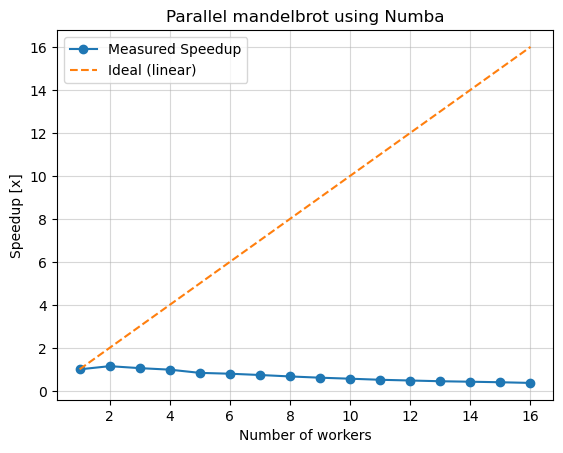

In [27]:
m3_results = pd.read_csv(m3_file)

workers = m3_results["total_workers"]
speedups = m3_results["speedup"]

ideal = range(1, len(speedups)+1)

plt.plot(workers, speedups, marker="o", label="Measured Speedup")
plt.plot(ideal, ideal, linestyle="--", label="Ideal (linear)")
plt.ylabel("Speedup [x]")
plt.xlabel("Number of workers")
plt.grid(alpha=0.5)
plt.legend()
plt.title("Parallel mandelbrot using chunks")
plt.show()

- **Back-solve implied $s = \frac{1/S_p^∗ − 1/p^*}{1 − 1/p^*}$**

In [28]:
speedups = list(speedups)

s_max = max(speedups)
p_star = speedups.index(s_max) + 1

s =  (1/s_max - 1/p_star) / (1 - 1/p_star)

print(f"Maximum speedup of {s_max:.2f}x achieved using {p_star} workers")
print(f"Back-solved: Approximately {s*100:.2f}% is serial.")

Maximum speedup of 1.15x achieved using 2 workers
Back-solved: Approximately 74.24% is serial.


- **Is your $s$ smaller than your L04 result?** - Better load balance ⇒ lower apparent $s$?

In lecture 4, we were only asked to backed-solve in *exercise* 3, question 3, which were about $\pi$ estimation and not mandelbrot set. Thus, I am unable to make a comparison.

#### ****3. Brief recommendation:****

- **What settings give the best time?**

The best parallel-chunked settings were achieved with just 2 workers.

- **Is parallelisation worth it on your hardware?** - Compare speedup and LIF to your serial
Numba baseline

Based on the speedup from the parallel chunked implementation, it is a clearly not worthwhile. Using just plain serial (precompiled) Numba is *way* faster.

*Comparing*: Speedup

$$\text{Speedup} = \frac{T_{\text{NumbaSerial}}}{T_{\text{ParallelChunked}}} = \frac{0.048 \text{s}}{0.269 \text{s}} = 0.18\times$$

$$\text{Slowdown} = \frac{T_{\text{ParallelChunked}}}{T_{\text{NumbaSerial}}} = \frac{0.269 \text{s}}{0.048 \text{s}} = 5.60\times$$

*Comparing*: LIF
$$ T_1 = 0.048 \text{s} \tag{Numba Baseline} $$

$$ T_p = T_{\text{ParallelChunked}} = 0.269 \text{s} $$

$$ p = 16 \tag{\text{os.cpu\_count()} }$$

$$\text{LIF} = \frac{p \cdot T_p}{T_1} - 1 = \frac{16 \cdot 0.269 \text{s}}{0.048 \text{s}} - 1 = 88.67\times $$

- **Write 2–3 sentences in your performance notebook**

Computing the mandelbrot set using Python's multiprocessing `Pool` combined with chunked tasks has proven to be a rather poor combination, resulting in *massive* overhead, as indicated by the Load Imbalance Factor (LIF) of $89\times$. Back-solving suggests that approximately $72\%$ of the workload behaves serially, likely  due to inter-process communication (IPC) overhead when scattering and gathering results. In fact, comparing this to Numba serial implementation resulted in a slowdown of $5.60\times$.

#### ****4. Submit to Performance Tracker:****

- **Enter your best multiprocessing time on Moodle - (1024×1024, Implementation: “Multiprocessing”)**

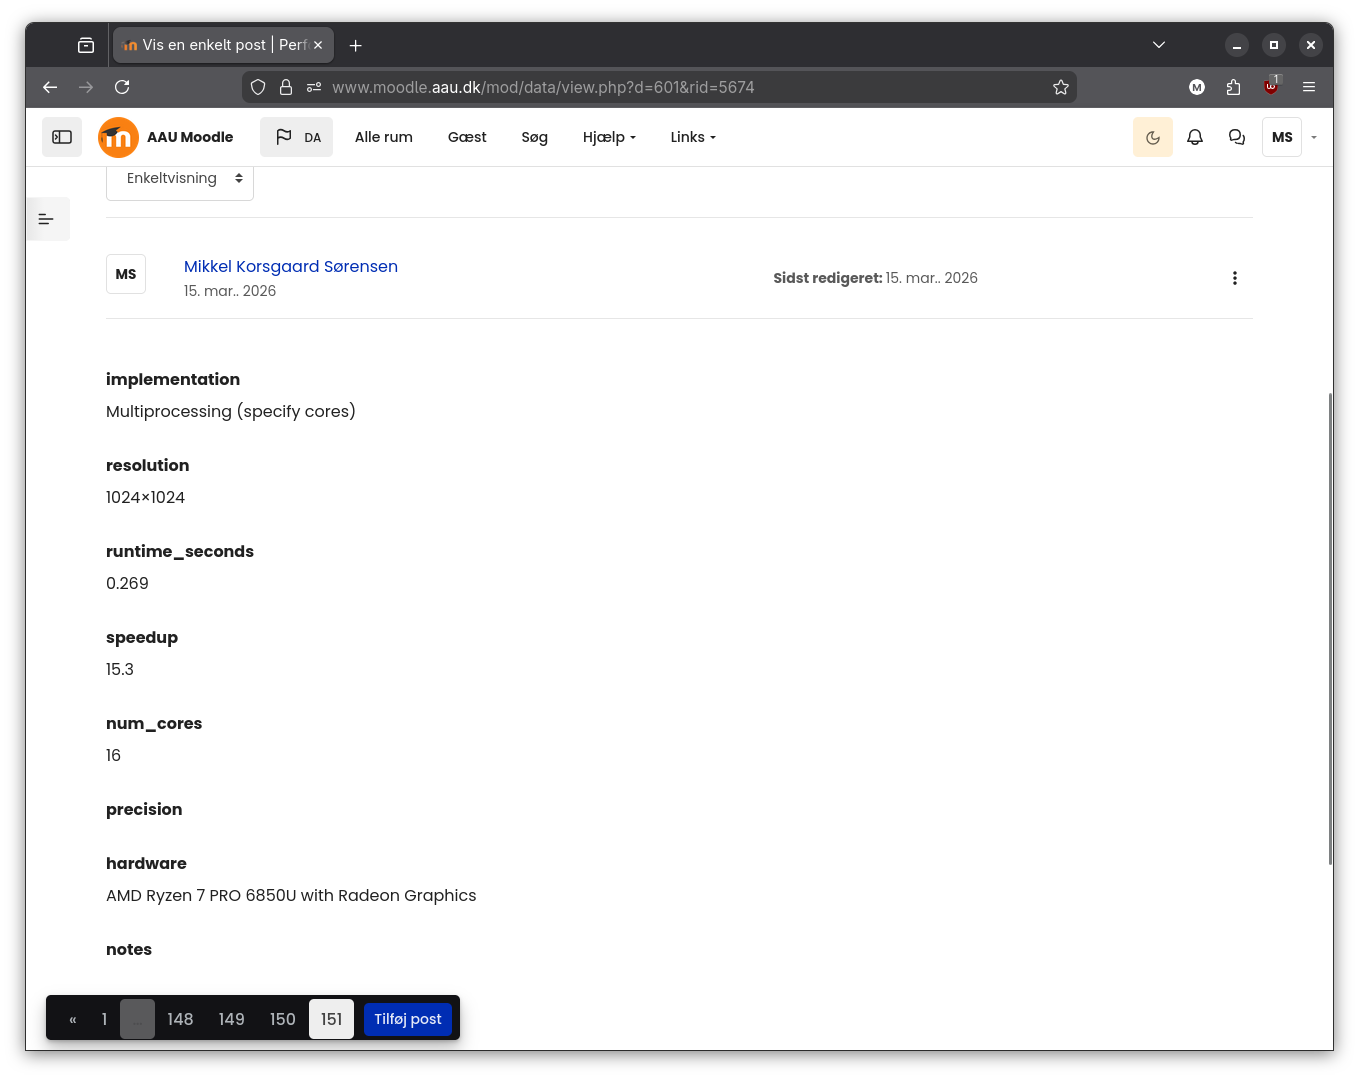

****Done?** Record all results in performance notebook (MP2) → commit**

```sh
┌──(mikkel@pella)-[~/Sync/AAU/Semester 8/github/nsc-mikkel]
└─$ git log -n 1
commit a8a32a5487c0c369f12222e9e324777cb2e74ee5 (HEAD -> main)
Author: mikkel-coder <mikkel.ks.sorensen@gmail.com>
Date:   Sun Mar 15 20:49:33 2026 +0000

    l05: milestone 3 done
```

## Lecture 6: Distributed Computing 1

### ****Milestone 1:** Dask Mandelbrot (local)**

****Approach:** wrap your existing `Numba_mandelbrot_chunk` with `dask.delayed` — same row-chunk structure as L04/L05, one task per row-band:**

`dask.compute(*[delayed(f)(args) for args in chunk args])` ← replaces `pool.map(f, chunk args)`

****Common pitfall:** Do NOT iterate Dask arrays inside the `max_iter` loop (e.g. `Z = da.where(...)`). Each of the 100 iterations becomes a separate task — $∼100,000$ tasks for $N = 1024$ — and overhead dominates. `dask.delayed` wraps the entire Numba function as *one* atomic task per chunk.**

In [15]:
# A copy from lecture 5

from numba import njit

# From slide 27, with the implementation filled in by me
# based on lecture 4.

# From L04 (unchanged — add `cache=True`` if not already there):
@njit(cache=True)
def mandelbrot_pixel(c_real, c_imag, max_iter):
    z_real = z_imag = 0.0
    for i in range(max_iter):
        zr2 = z_real*z_real
        zi2 = z_imag*z_imag
        if zr2 + zi2 > 4.0: return i
        z_imag = 2.0*z_real*z_imag + c_imag
        z_real = zr2 - zi2 + c_real
    return max_iter

@njit(cache=True)
def mandelbrot_chunk(row_start, row_end, N, x_min, x_max, y_min, y_max, max_iter):
    out = np.empty((row_end - row_start, N), dtype=np.int32)
    dx = (x_max - x_min) / N
    dy = (y_max - y_min) / N
    for r in range(row_end - row_start):
        c_imag = y_min + (r + row_start) * dy
        for col in range(N):
            out[r, col] = mandelbrot_pixel(x_min + col*dx, c_imag, max_iter)
    return out

def _worker(args): 
    return mandelbrot_chunk(*args) # plain Python, must be module-level

In [16]:
# From slide 34

from dask import delayed
from dask.distributed import Client, LocalCluster
import dask, numpy as np, time, statistics
# mandelbrot_chunk: your @njit(cache=True) function from L04/L05
def mandelbrot_dask(N, x_min, x_max, y_min, y_max,
                    max_iter=100, n_chunks=32):
    chunk_size = max(1, N // n_chunks)
    tasks, row = [], 0
    while row < N:
        row_end = min(row + chunk_size, N)
        tasks.append(delayed(mandelbrot_chunk)(
            row, row_end, N, x_min, x_max, y_min, y_max, max_iter))
        row = row_end
    parts = dask.compute(*tasks)
    return np.vstack(parts)

if __name__ == '__main__':
    N, max_iter = 1024, 100
    X_MIN, X_MAX, Y_MIN, Y_MAX = -2.5, 1.0, -1.25, 1.25
    cluster = LocalCluster(n_workers=8, threads_per_worker=1)
    client = Client(cluster)
    client.run(lambda: mandelbrot_chunk(0, 8, 8, X_MIN, X_MAX, # warm up all workers
                                        Y_MIN, Y_MAX, 10))
    times = []
    for _ in range(3):
        t0 = time.perf_counter()
        result = mandelbrot_dask(N, X_MIN, X_MAX, Y_MIN, Y_MAX, max_iter)
        times.append(time.perf_counter() - t0)
    print(f"Dask local (n_chunks=32): {statistics.median(times):.3f} s")
    client.close(); cluster.close()

Dask local (n_chunks=32): 0.062 s


**1. Implement `mandelbrot_dask()` using `dask.delayed` (see code example).**

Done. Please see the code above.

**2. Verify: `np.array_equal(ref, result)` against your serial output.**

In [17]:
# Serial
ref = mandelbrot_chunk(0, N, N, X_MIN, X_MAX, Y_MIN, Y_MAX, max_iter)

assert np.array_equal(ref, result)

**3. Warm up Numba JIT in *all* workers with `client.run()` before timing.**

Done. Please see the main code block above.

**4. Time 3 runs; record `statistics.median()`.**

Done.

****Done?** Record time in performance notebook (MP2) → commit**

```sh
┌──(mikkel@pella)-[~/Sync/AAU/Semester 8/github/nsc-mikkel]
└─$ git log -n 1
commit 52996111e6d3f507b4df00e0c2e4b6d3658df8f1 (HEAD -> main)
Author: mikkel-coder <mikkel.ks.sorensen@gmail.com>
Date:   Tue Mar 24 19:39:35 2026 +0000

    l06: milestone 1 done
```

### ****Milestone 2:** Chunk size sweep**

**Find the optimal chunk count for Dask local on your machine.**

****Sweep** `n_chunks` over a range guided by the three-way trade-off (see theory slides). For each setting: time 3 runs (median), compute $LIF = p \cdot T_p / T_1 − 1$.**

**1. Adapt your L05 Dask implementation to loop over `n_chunks` values: keep `LocalCluster` open across all measurements (start-up cost paid once).**

*Note:* We did not work with Dask in lecture five. I am unsure why this exercise thinks so.

In [18]:
def compute_ms1():
    N, max_iter = 1024, 100
    X_MIN, X_MAX, Y_MIN, Y_MAX = -2.5, 1.0, -1.25, 1.25
    cluster = LocalCluster(n_workers=8, threads_per_worker=1)
    client = Client(cluster)
    client.run(lambda: mandelbrot_chunk(0, 8, 8, X_MIN, X_MAX,  # warm up all workers
                                        Y_MIN, Y_MAX, 10))

    n_chunks_arr = [1, 2, 4, 8, 16, 32]
    times_res = []
    lifs = []
    vs1x = []
    speedups = []

    for n_chunks in n_chunks_arr:
        times = []
        for _ in range(3):
            t0 = time.perf_counter()
            result = mandelbrot_dask(
                N, X_MIN, X_MAX, Y_MIN, Y_MAX, max_iter, n_chunks)
            times.append(time.perf_counter() - t0)

        T_p = statistics.median(times)
        times_res.append(T_p)
        T_1 = times_res[0]
        vs1x.append(T_p / T_1)
        speedups.append(T_1 / T_p)
        lifs.append(8 * T_p / T_1 - 1)

    client.close()
    cluster.close()

    return n_chunks_arr, times_res, vs1x, speedups, lifs

In [19]:
from pathlib import Path
import pandas as pd

ms1_file = Path("l06_milestone1.csv")

if not ms1_file.exists():
    n_chunks, times, vs1x, speedups, lifs = compute_ms1()
    df = pd.DataFrame({
        "n_chunks": n_chunks,
        "time": times,
        "vs1x": vs1x,
        "speedup": speedups,
        "lif": lifs
    })
    df.to_csv(ms1_file, index_label=False)

**2. Warm up Numba JIT in *all* workers with `client.run()` before the sweep loop.**

Done! Please see the code above.

**3. Record: wall time and LIF per `n_chunks`; plot wall time vs. n_chunks (log scale).**

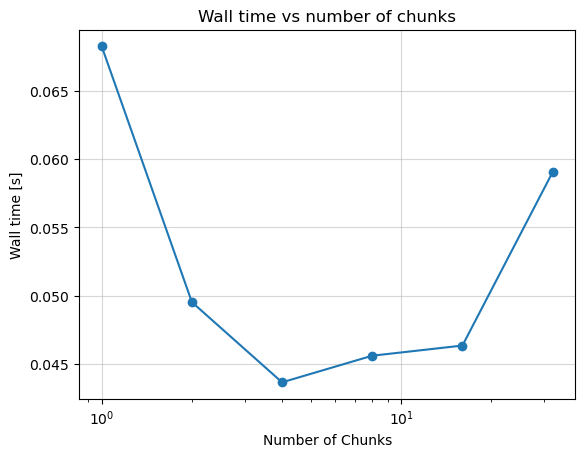

In [20]:
import matplotlib.pyplot as plt


ms1_results = pd.read_csv(ms1_file)

wall_time = ms1_results["time"]
n_chunks = ms1_results["n_chunks"]

plt.plot(n_chunks, wall_time, marker="o")
plt.xscale("log")
plt.xlabel("Number of Chunks")
plt.ylabel("Wall time [s]")
plt.grid(alpha=0.5)
plt.title("Wall time vs number of chunks")
plt.savefig("dask_chunk_sweep.png")
plt.show()


**4. Note: Dask has higher $\alpha$ per task than multiprocessing — expect the optimal `n_chunks` to be smaller than in L05.**

Sure..... Noted.

****Print table columns:****

**`n_chunks | time (s) | vs 1x | speedup | LIF`**

In [21]:
from IPython.display import Markdown, display

df_display = ms1_results.copy()
df_display["n_chunks"] = df_display["n_chunks"].map("{:>2}".format)
df_display["time"] = df_display["time"].map("{:>.3f}s".format)
df_display["vs1x"] = df_display["vs1x"].map("{:>.2f}x".format)
df_display["speedup"] = df_display["speedup"].map("{:>.2f}x".format)
df_display["lif"] = df_display["lif"].map("{:>.2f}".format)

display(Markdown(df_display.to_markdown(index=False)))

|   n_chunks | time   | vs1x   | speedup   |   lif |
|-----------:|:-------|:-------|:----------|------:|
|          1 | 0.068s | 1.00x  | 1.00x     |  7    |
|          2 | 0.050s | 0.73x  | 1.38x     |  4.81 |
|          4 | 0.044s | 0.64x  | 1.56x     |  4.12 |
|          8 | 0.046s | 0.67x  | 1.50x     |  4.35 |
|         16 | 0.046s | 0.68x  | 1.47x     |  4.43 |
|         32 | 0.059s | 0.87x  | 1.16x     |  5.92 |

****Record:****

**`n_chunks_optimal, t_min, LIF_min`**

**Save plot as `dask_chunk_sweep.png`**

In [22]:
row_idx = ms1_results["time"].idxmin()

n_chunks_optimal = int(ms1_results.iloc[row_idx]["n_chunks"])
t_min = float(ms1_results.iloc[row_idx]["time"])
LIF_min = float(ms1_results.iloc[row_idx]["lif"])

print(f"{n_chunks_optimal=}")
print(f"{t_min=:.3f}s")
print(f"{LIF_min=:.2f}")

n_chunks_optimal=4
t_min=0.044s
LIF_min=4.12


****Optional:** Add block-level early exit to your Numba kernel: after each iteration step, check if all pixels in the chunk have diverged — if so, break the loop. Chunks entirely outside the Mandelbrot set then skip remaining iterations. Compare timing with and without this optimisation.**

In [23]:
from numba import njit
import numpy as np

@njit(cache=True)
def mandelbrot_chunk_early(row_start, row_end, N, x_min, x_max, y_min, y_max, max_iter):
    out = np.zeros((row_end - row_start, N), dtype=np.int32)
    dx = (x_max - x_min) / N
    dy = (y_max - y_min) / N

    z_real = np.zeros_like(out)
    z_imag = np.zeros_like(out)
    alive = np.ones_like(out)
    escaped = np.zeros_like(out, dtype=np.bool_)

    # Mach forward per iterations
    for i in range(max_iter):

        # EXIT if all chunks are done (EXTREMELY UNLIKELY)
        if not np.any(alive):
            break

        # For each chunk
        for row in range(row_end - row_start):

            # EARLY EXIT CHUNK
            if not np.any(alive[row, :]):
                continue

            c_imag = y_min + (row + row_start) * dy

            # For each pixel in chunk
            for col in range(N):

                # mandelbrot pixel
                zr2 = z_real[row, col] * z_real[row, col]
                zi2 = z_imag[row, col] * z_imag[row, col]
                if zr2 + zi2 > 4.0:
                    if not out[row, col]:
                        out[row, col] = i
                        escaped[row, col] = True
                    alive[row, col] = 0 # Keep nagging the chunk. We are dead

                # The "expense" of not escaping pixel wise
                z_imag[row, col] = 2.0*z_real[row, col]*z_imag[row, col] + c_imag
                z_real[row, col] = zr2 - zi2 + x_min + col*dx

    # I wished numba supported binary masks :(
    # out[escaped != True ] = max_tier
    for row in range(row_end - row_start):
        for col in range(N):
            if not escaped[row, col]:
                out[row, col] = max_iter
    
    return out

*Note:* that we must change the following:
- $z$ must now be stored per pixel. Comparing to before, it was local function scoped within `mandelbrot_pixel()`
- We must also now keep track of which pixels in a chunk are done, in order to determine if we totally done image wise.
- Some points never reach `max_iter` and some points exit *very* early, both cases result in its pixel value staying at $0$. To separate them, a binary mask is used.

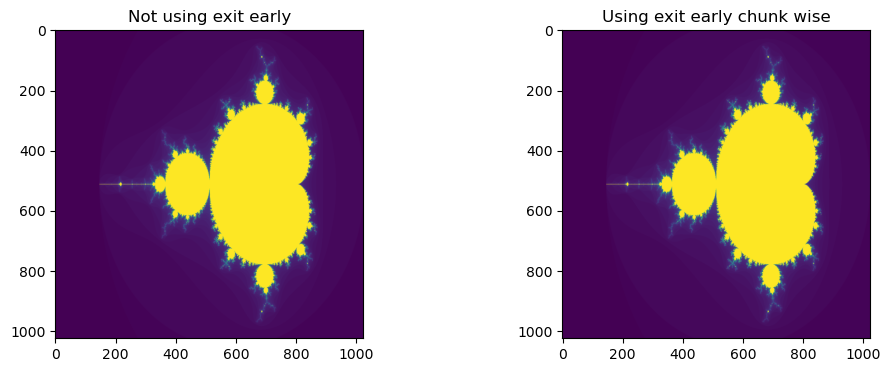

In [24]:
image_normal = mandelbrot_chunk(0, 1024, 1024, -2.5, 1.0, -1.25, 1.25, max_iter=100)
image_early = mandelbrot_chunk_early(0, 1024, 1024, -2.5, 1.0, -1.25, 1.25, max_iter=100)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(image_normal)
axes[0].set_title("Not using exit early")
axes[1].imshow(image_early)
axes[1].set_title("Using exit early chunk wise")
plt.show()

assert np.array_equal(image_normal, image_early)

Lets also time them.

In [25]:
def benchmark(func: callable, args):
    func(*args)  # warm up

    times = []
    for _ in range(3):
        t0 = time.perf_counter()
        _ = func(*args)
        times.append(time.perf_counter() - t0)

    return statistics.median(times)


time_normal = benchmark(
    mandelbrot_chunk, (0, 1024, 1024, -2.5, 1.0, -1.25, 1.25, 100)
)
time_early = benchmark(
    mandelbrot_chunk_early, (0, 1024, 1024, -2.5, 1.0, -1.25, 1.25, 100)
)

print(f"NOT using early stop:\t{time_normal:.3f}s")
print(f"Using early stop:\t{time_early:.3f}s")

NOT using early stop:	0.069s
Using early stop:	0.215s


I suspect that the slowdown is due to more active memory access patterns and that we are using about $4\times$ as much (global) memory.

****Done?** Record `n_chunks` optimal and `LIF_min` in performance notebook (MP2) → commit**

```sh
┌──(mikkel@pella)-[~/Sync/AAU/Semester 8/github/nsc-mikkel]
└─$ git log -n 1
commit 2afef423b93a5df80b973ea512823fec74814000 (HEAD -> main)
Author: mikkel-coder <mikkel.ks.sorensen@gmail.com>
Date:   Wed Mar 25 21:32:19 2026 +0000

    l06: milestone 2 done
```

### ****Milestone 3:** Full benchmark (all methods)**

**Collect all timings and compare every implementation built so far.**

**Add a Dask row to your performance notebook:**

| **Implementation**      | **Time (s)**        | **Speedup vs. naive** |
| ----------------------- | ------------------- | --------------------- |
| Naive Python            |                     | 1×                    |
| NumPy                   |                     |                       |
| Numba (@njit)           |                     |                       |
| Numba + multiprocessing |                     |                       |
| Dask local              |                     |                       |
| Dask cluster            | (to be added in L7) |                       |


Here is my table:

| **Implementation**      | **Time (s)**        | **Speedup vs. naive** |
| ----------------------- | ------------------- | --------------------- |
| Naive Python            | 4.113s              | 1×                    |
| NumPy                   | 0.578s              | 6.85x                 |
| Numba (@njit)           | 0.048s              | 86.6x                 |
| Numba + multiprocessing | 0.269s              | 15.3X                 |
| Dask local              | 0.044s              | 93.4x                 |
| Dask cluster            | -                   | -                     |

**Reflection questions (address in your written reflection):**

- **How does Dask local compare to multiprocessing at the same worker count?**

Using "Dask local" is $\frac{0.269 \text{s}}{0.044 \text{s}} = 6.11\times$ faster than using "Numba + multiprocessing" both using the same number of cores. I suspect that "Numba + multiprocessing" is slower since we must use the Pythons `Pool.map()`. Perhaps Dask IPC is more efficient and faster than Python.

- **What does the overhead difference tell you about when to choose each tool?**

I would chose my tools in the following order:

1. *Numba (@njit):* Compiled machine code is often about $~100\times$ faster than Python. Combing both Python and machine code is very easy to do with Numba, but it does not work in some scenarios.
2. *Dask Local (with Numba):* Scaling compiled Python code with Dask is easy to program, also helping with scaling to hounders of computers.

The other options are not very performant. It is always a trade-off between easy of implementation and platform integration (Python vs C vs CUDA for example). 

****Submit:** Add your Dask local result to the Performance Tracker in Moodle.**

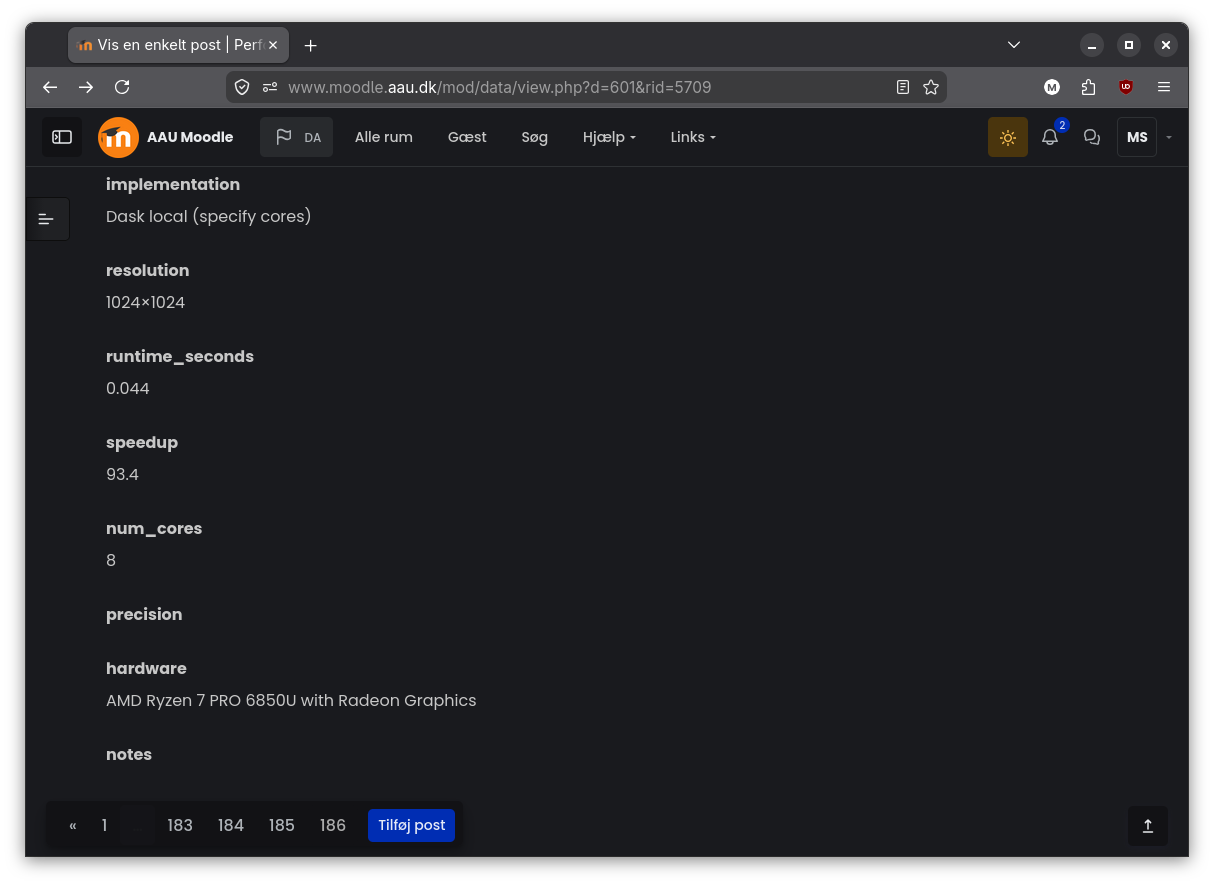

****Done?** Record all results in performance notebook (MP2) → commit**

```sh
┌──(mikkel@pella)-[~/Sync/AAU/Semester 8/github/nsc-mikkel]
└─$ git log -n 1
commit e7ba37c5b3ff0188601e18035a7c1cea72d651b9 (HEAD -> main)
Author: mikkel-coder <mikkel.ks.sorensen@gmail.com>
Date:   Wed Mar 25 22:02:30 2026 +0000

    l06: milestone 3 done
```

### **Section 2: Dask Local**

#### **Timing at ≥4096×4096 and speedup vs Numba single-core**

In [1]:
import numpy as np
# A copy from lecture 6, milestone 1

# A copy from lecture 5

from numba import njit

# From slide 27, with the implementation filled in by me
# based on lecture 4.

# From L04 (unchanged — add `cache=True`` if not already there):
@njit(cache=True)
def mandelbrot_pixel(c_real, c_imag, max_iter):
    z_real = z_imag = 0.0
    for i in range(max_iter):
        zr2 = z_real*z_real
        zi2 = z_imag*z_imag
        if zr2 + zi2 > 4.0: return i
        z_imag = 2.0*z_real*z_imag + c_imag
        z_real = zr2 - zi2 + c_real
    return max_iter

@njit(cache=True)
def mandelbrot_chunk(row_start, row_end, N, x_min, x_max, y_min, y_max, max_iter):
    out = np.empty((row_end - row_start, N), dtype=np.int32)
    dx = (x_max - x_min) / N
    dy = (y_max - y_min) / N
    for r in range(row_end - row_start):
        c_imag = y_min + (r + row_start) * dy
        for col in range(N):
            out[r, col] = mandelbrot_pixel(x_min + col*dx, c_imag, max_iter)
    return out

In [2]:
# Mostly a copy from Lecture 6, Milestone 1

# From slide 34

from dask import delayed
from dask.distributed import Client, LocalCluster
import dask, numpy as np, time, statistics
# mandelbrot_chunk: your @njit(cache=True) function from L04/L05
def mandelbrot_dask(N, x_min, x_max, y_min, y_max,
                    max_iter=100, n_chunks=32):
    chunk_size = max(1, N // n_chunks)
    tasks, row = [], 0
    while row < N:
        row_end = min(row + chunk_size, N)
        tasks.append(delayed(mandelbrot_chunk)(
            row, row_end, N, x_min, x_max, y_min, y_max, max_iter))
        row = row_end
    parts = dask.compute(*tasks)
    return np.vstack(parts)

In [3]:
# Mostly a copy of my own code from Lecture 6, Milestone 2
# but using 4096x4096 instead excluding chunk sweep.

def compute_mp2_section2():
    n_sizes = [512, 1024, 2048, 4096]
    max_iter = 100
    X_MIN, X_MAX, Y_MIN, Y_MAX = -2.5, 1.0, -1.25, 1.25
    cluster = LocalCluster(n_workers=8, threads_per_worker=1)
    client = Client(cluster)
    client.run(lambda: mandelbrot_chunk(0, 8, 8, X_MIN, X_MAX,  # warm up all workers
                                        Y_MIN, Y_MAX, 10))

    times_res = []

    for n in n_sizes:
        times = []
        for _ in range(3):
            t0 = time.perf_counter()
            result = mandelbrot_dask(
                n, X_MIN, X_MAX, Y_MIN, Y_MAX, max_iter)
            times.append(time.perf_counter() - t0)

        T_p = statistics.median(times)
        times_res.append(T_p)

    client.close()
    cluster.close()

    return n_sizes, times_res

In [4]:
from pathlib import Path
import pandas as pd

mp2_section2 = Path("mp2_section2.csv")

if not mp2_section2.exists():
    n_sizes, times, = compute_mp2_section2()
    df = pd.DataFrame({
        "n_size": n_sizes, 
        "time": times,
    })
    df.to_csv(mp2_section2, index_label=False)

In [5]:
from IPython.display import Markdown, display

mp2_section2 = pd.read_csv(mp2_section2)

t0 = 0.71728592099862  # serial numba result from lecture 7
mp2_section2["speedup"] = t0 / mp2_section2["time"]


mp2_section2["n_size"] = mp2_section2["n_size"].map("{:>2}".format)
mp2_section2["time"] = mp2_section2["time"].map("{:>.3f}s".format)
mp2_section2["speedup"] = mp2_section2["speedup"].map("{:>.2f}x".format)

display(Markdown(mp2_section2.to_markdown(index=False)))

|   n_size | time   | speedup   |
|---------:|:-------|:----------|
|      512 | 0.052s | 13.70x    |
|     1024 | 0.059s | 12.10x    |
|     2048 | 0.088s | 8.13x     |
|     4096 | 0.266s | 2.70x     |

## Lecture 7: Distributed Dask in Practice

### ****Milestone 1:** Dask Mandelbrot on Strato cluster**

****Grid size:** use $N = 4096$ (or larger) — 1024 is too small; network overhead dominates and speedup is marginal. Also run a serial Numba baseline at the same resolution to compute speedup.**

#### **What to Benchmark**

##### ****Experiment 1:** Chunk size sweep**

**Fix all worker VMs connected; vary chunk size.**

- **Record wall time (median of 3 runs) per chunk size**

Please see the document "l07_strato_dask_setup.ipynb" in part 5. In that exercise I varied the number of chunks and workers. I used $N=4096$.

In [1]:
import pandas as pd
from IPython.display import display, Markdown

df = pd.read_csv("l07_part5.csv")
df["time"] = df["time"].map("{:>.3f}s".format)
display(Markdown(df[["workers", "chunks", "time"]].to_markdown(index=False)))

|   workers |   chunks | time   |
|----------:|---------:|:-------|
|         1 |        1 | 1.646s |
|         1 |        2 | 0.907s |
|         1 |        4 | 0.918s |
|         1 |        8 | 1.011s |
|         1 |       16 | 1.011s |
|         1 |       32 | 0.984s |
|         2 |        1 | 1.527s |
|         2 |        2 | 0.933s |
|         2 |        4 | 0.858s |
|         2 |        8 | 0.758s |
|         2 |       16 | 0.646s |
|         2 |       32 | 0.598s |
|         3 |        1 | 1.700s |
|         3 |        2 | 0.951s |
|         3 |        4 | 0.841s |
|         3 |        8 | 0.873s |
|         3 |       16 | 0.540s |
|         3 |       32 | 0.559s |

- **Note best chunk size**

Please see the document "l07_strato_dask_setup.ipynb" in part 5. In that exercise I varied the number of chunks and workers.

In [2]:
import pandas as pd

df = pd.read_csv("l07_part5.csv")

row_idx = df["time"].idxmin()
best_chunk_size = int(df.iloc[row_idx]["chunks"])
best_workers = int(df.iloc[row_idx]["workers"])

print(f"Best chunk size of {best_chunk_size} using {best_workers} workers nodes")

Best chunk size of 16 using 3 workers nodes


- **How does it compare to your L06-M2 result?**

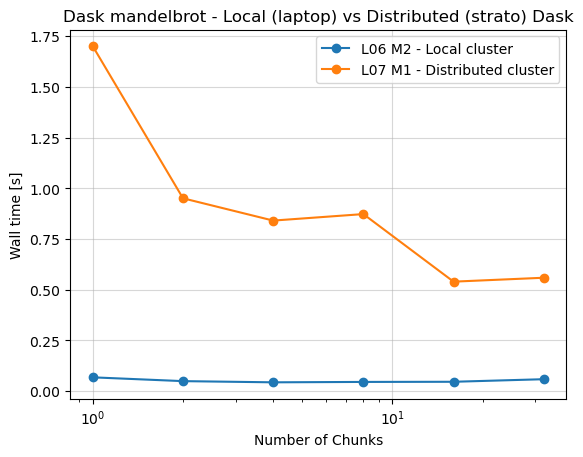

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Include result form both L06 milestone 1 and 2
l06_m2 = pd.read_csv("l06_milestone1.csv")
l07_m1 = pd.read_csv("l07_part5.csv")

# Using 3 worker nodes, in total 2*3 = 6 threads.
# Lecture 6 used 8 threads/workers in total.
l07_m1_subset = l07_m1.loc[l07_m1["workers"] == 3]

l06_m2_time = l06_m2["time"]
l06_m2_chunks = l06_m2["n_chunks"]

l07_m1_subset_time = l07_m1_subset["time"]
l07_m1_subset_chunks = l07_m1_subset["chunks"]

# plot
plt.plot(l06_m2_chunks, l06_m2_time, marker="o", label="L06 M2 - Local cluster")
plt.plot(l07_m1_subset_chunks, l07_m1_subset_time, marker="o", label="L07 M1 - Distributed cluster")
plt.xscale("log")
plt.xlabel("Number of Chunks")
plt.ylabel("Wall time [s]")
plt.grid(alpha=0.5)
plt.title("Dask mandelbrot - Local (laptop) vs Distributed (strato) Dask")
plt.legend()
plt.show()

Let's also plot the speedups.

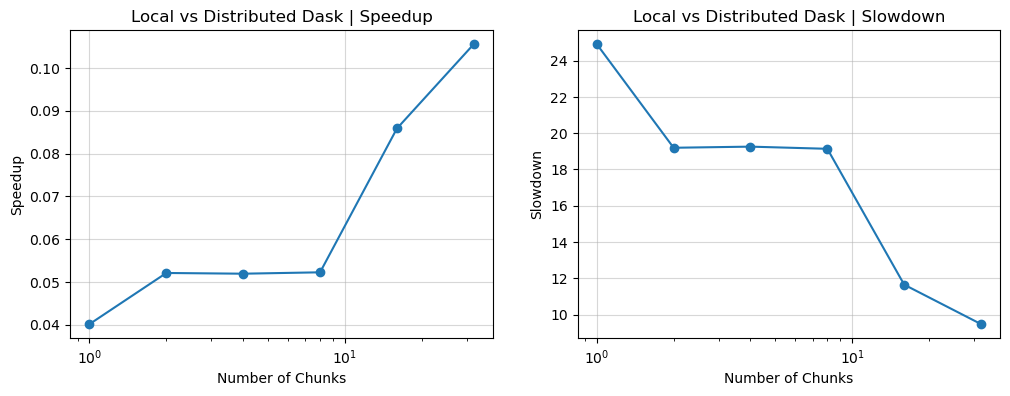

In [4]:
speedups = np.array(l06_m2_time) / np.array(l07_m1_subset_time)
slowdowns = 1 / speedups

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Speedup
axes[0].plot(l06_m2_chunks, speedups, marker="o")
axes[0].set_xscale("log")
axes[0].set_xlabel("Number of Chunks")
axes[0].set_ylabel("Speedup")
axes[0].grid(alpha=0.5)
axes[0].set_title("Local vs Distributed Dask | Speedup")

# Slowdown
axes[1].plot(l06_m2_chunks, slowdowns, marker="o")
axes[1].set_xscale("log")
axes[1].set_xlabel("Number of Chunks")
axes[1].set_ylabel("Slowdown")
axes[1].grid(alpha=0.5)
axes[1].set_title("Local vs Distributed Dask | Slowdown")
plt.show()

Please note that Lecture 6 used a size of 1024 and 8 workers, while Lecture 7 used a size of 4096 with 6 workers. I would personally not compare them, but I have done as told so. To no surprise, the local cluster is WAY faster than the Strato cluster. We also see that, as the number of chunks grows, the Strato cluster becomes faster, which is to be expected.

##### ****Experiment 2:** Worker scaling**

**Fix best chunk size; vary number of active worker VMs.**

- **Start `dask-worker` on one VM; benchmark**

- **Add the next VM; benchmark again**

- **Repeat up to all VMs**

Please see the document "l07_strato_dask_setup.ipynb" in part 5. In that exercise I varied the number of chunks and workers.

- **Does wall time scale linearly with worker count?**

In [5]:
df = pd.read_csv("l07_part5.csv")
df_subset = df.loc[df["chunks"] == best_chunk_size]

df_subset["time"] = df_subset["time"].map("{:>.3f}s".format)

print(f"Best chunk size was {best_chunk_size}")
display(Markdown(df_subset[["workers", "time"]].to_markdown(index=False)))

Best chunk size was 16


|   workers | time   |
|----------:|:-------|
|         1 | 1.011s |
|         2 | 0.646s |
|         3 | 0.540s |

#### **Record in Performance Notebook**

- **Cluster configuration: number of worker VMs, vCPUs per VM, total workers**

Please see the document "l07_strato_dask_setup.ipynb" part 5 for more info.

- *Number of worker VMs*: 1-3
- *vCPU*: `AAU.CPU.b.2-4` (2 workers per VM)
- *Total workers*: 2-6


- **Grid size $N$ and `max_iter` used**

Please see the document "l07_strato_dask_setup.ipynb" part 5 for more info.

- *Grid size*: 4096
- *`max_iter`*: 100

- **Best chunk size from sweep and corresponding wall time**

Please see the document "l07_strato_dask_setup.ipynb" part 5 for more info.

- *Best chunk size:* 16
- *Best chunk size wall time:* 0.540s

- **Worker scaling: wall time vs. worker count (table or plot)**

Please see the table above in experiment number 2.

- **Speedup vs. serial Numba at the same resolution**

Please see the document "l07_strato_dask_setup.ipynb" in part 5 for more info. In that, I compared the speedup vs Numba serial. Here, I only plot the results.

In [6]:
# From exercise 1

from IPython.display import Markdown, display
import pandas as pd

df = pd.read_csv("l07_part5.csv")

# Compute speedups
t0 = 0.71728592099862 # serial numba
df["speedup"] = t0 / df["time"]

# Display as table
df["time"] = df["time"].map("{:>.3f}s".format)
df["speedup"] = df["speedup"].map("{:>.2f}x".format)
display(Markdown(df[["workers", "chunks", "time", "speedup"]].to_markdown(index=False)))

|   workers |   chunks | time   | speedup   |
|----------:|---------:|:-------|:----------|
|         1 |        1 | 1.646s | 0.44x     |
|         1 |        2 | 0.907s | 0.79x     |
|         1 |        4 | 0.918s | 0.78x     |
|         1 |        8 | 1.011s | 0.71x     |
|         1 |       16 | 1.011s | 0.71x     |
|         1 |       32 | 0.984s | 0.73x     |
|         2 |        1 | 1.527s | 0.47x     |
|         2 |        2 | 0.933s | 0.77x     |
|         2 |        4 | 0.858s | 0.84x     |
|         2 |        8 | 0.758s | 0.95x     |
|         2 |       16 | 0.646s | 1.11x     |
|         2 |       32 | 0.598s | 1.20x     |
|         3 |        1 | 1.700s | 0.42x     |
|         3 |        2 | 0.951s | 0.75x     |
|         3 |        4 | 0.841s | 0.85x     |
|         3 |        8 | 0.873s | 0.82x     |
|         3 |       16 | 0.540s | 1.33x     |
|         3 |       32 | 0.559s | 1.28x     |

****Also add a Numba serial entry to the performance tracker** at the same resolution as your clusterruns — this enables a meaningful speedup comparison across the class.**

In [7]:
# From lecture 3

# from slide 37. Approach B
from numba import njit
import numpy as np


@njit                       # <-- entire function compiled !
def mandelbrot_naive_numba(xmin, xmax, ymin, ymax, width, height, max_iter=100):
    """Fully JIT - compiled Mandelbrot --- structure identical to naive."""
    x = np.linspace(xmin, xmax, width)
    y = np.linspace(ymin, ymax, height)
    result = np.zeros((height, width), dtype=np.int32)

    for i in range(height):             # compiled loop
        for j in range(width):          # compiled loop
            c = x[j] + 1j * y[i]
            z = 0j                      # complex literal: type inference works!
            n = 0
            while n < max_iter and (z.real*z.real + z.imag*z.imag) <= 4.0:
                z = z*z + c
                n += 1
            result[i, j] = n
    return result

In [8]:
# From lecture 5

from numba import njit

# From slide 27, with the implementation filled in by me
# based on lecture 4.

# From L04 (unchanged — add `cache=True`` if not already there):
@njit(cache=True)
def mandelbrot_pixel(c_real, c_imag, max_iter):
    z_real = z_imag = 0.0
    for i in range(max_iter):
        zr2 = z_real*z_real
        zi2 = z_imag*z_imag
        if zr2 + zi2 > 4.0: return i
        z_imag = 2.0*z_real*z_imag + c_imag
        z_real = zr2 - zi2 + c_real
    return max_iter

@njit(cache=True)
def mandelbrot_chunk(row_start, row_end, N, x_min, x_max, y_min, y_max, max_iter):
    out = np.empty((row_end - row_start, N), dtype=np.int32)
    dx = (x_max - x_min) / N
    dy = (y_max - y_min) / N
    for r in range(row_end - row_start):
        c_imag = y_min + (r + row_start) * dy
        for col in range(N):
            out[r, col] = mandelbrot_pixel(x_min + col*dx, c_imag, max_iter)
    return out

def _worker(args): 
    return mandelbrot_chunk(*args) # plain Python, must be module-level

In [9]:
from multiprocessing import Pool
# From lecture 5

# From slide 27

# Extend your L04 mandelbrot parallel to (include n chunks):
def mandelbrot_parallel(N, x_min, x_max, y_min, y_max,
                        max_iter=100, n_workers=4, n_chunks=None):
    if n_chunks is None:
        n_chunks = n_workers
    chunk_size = max(1, N // n_chunks)
    chunks, row = [], 0
    while row < N:
        row_end = min(row + chunk_size, N)
        chunks.append((row, row_end, N, x_min, x_max, y_min, y_max, max_iter))
        row = row_end
    tiny = [(0, 8, 8, x_min, x_max, y_min, y_max, max_iter)]
    with Pool(processes=n_workers) as pool:
        pool.map(_worker, tiny)         # warm-up: load JIT cache in workers
        parts = pool.map(_worker, chunks)
    return np.vstack(parts)

In [10]:
# From lecture 6

# From slide 34

from dask import delayed
from dask.distributed import Client, LocalCluster
import dask, numpy as np, time, statistics
# mandelbrot_chunk: your @njit(cache=True) function from L04/L05
def mandelbrot_dask(N, x_min, x_max, y_min, y_max,
                    max_iter=100, n_chunks=32):
    chunk_size = max(1, N // n_chunks)
    tasks, row = [], 0
    while row < N:
        row_end = min(row + chunk_size, N)
        tasks.append(delayed(mandelbrot_chunk)(
            row, row_end, N, x_min, x_max, y_min, y_max, max_iter))
        row = row_end
    parts = dask.compute(*tasks)
    return np.vstack(parts)

In [11]:
import pandas as pd
import time
# Copied mostly form lecture 6, my own benchmark function

def benchmark(name: str, func: callable):
    # skip benchmarking if needed
    if name == "Dask cluster":
        df = pd.read_csv("l07_part5.csv")
        time_res = df[(df["workers"] == 3) & (df["chunks"] == 16)]["time"].iloc[0]
        return time_res
    
    # Dask local cluster
    if func is mandelbrot_dask:
        cluster = LocalCluster(n_workers=8, threads_per_worker=1)
        client = Client(cluster)

    func()  # warm up

    times = []
    for _ in range(3):
        t0 = time.perf_counter()
        _ = func()
        times.append(time.perf_counter() - t0)
    
    if func is mandelbrot_dask:
        client.close()
        cluster.close()

    return statistics.median(times)

In [12]:
from mandelbrot import compute_mandelbrot
from mandelbrot import compute_mandelbrot_numpy

def compute_ms1():
    # Same names as the ones one moodle
    impl: dict[str, callable] = {
        "Naive Python": lambda: compute_mandelbrot(x_min=-2, x_max=1, y_min=-1.5, y_max=1.5, width=4096, height=4096, max_iter=100),
        "Numpy vectorized": lambda: compute_mandelbrot_numpy(x_min=-2, x_max=1, y_min=-1.5, y_max=1.5, width=4096, height=4096, max_iter=100),
        "Numba JIT": lambda: mandelbrot_naive_numba(xmin=-2, xmax=1, ymin=-1.5, ymax=1.5, width=4096, height=4096, max_iter=100),
        "Multiprocessing": lambda: mandelbrot_parallel(N=4096, x_min=-2, x_max=1, y_min=-1.5, y_max=1.5, max_iter=100, n_workers=8, n_chunks=16),
        "Dask local": lambda: mandelbrot_dask(N=4096, x_min=-2, x_max=1, y_min=-1.5, y_max=1.5, max_iter=100, n_chunks=16),
        "Dask cluster": None, # Reuse results in csv file
    }

    names = []
    times = []
    speedups = []

    for name, func in impl.items():
        time = benchmark(name, func)
        
        times.append(time)
        names.append(name)
        t0 = times[0]
        speedups.append(t0 / time)
    
    return names, times, speedups

In [13]:
from pathlib import Path

ms1_file = Path("l07_ms1.csv")
if not ms1_file.exists():
    impl, times, speedups = compute_ms1()
    df = pd.DataFrame({
        "implementation": impl,
        "time": times,
        "speedup": speedups
    })
    df.to_csv(ms1_file, index_label=False)

****Done?** Record results in performance notebook (MP2) → commit**

In [14]:
from IPython.display import Markdown, display

df_display = pd.read_csv(ms1_file)
df_display["implementation"] = df_display["implementation"].map("{:>2}".format)
df_display["time"] = df_display["time"].map("{:>.3f}s".format)
df_display["speedup"] = df_display["speedup"].map("{:>.2f}x".format)

display(Markdown(df_display.to_markdown(index=False)))

| implementation   | time    | speedup   |
|:-----------------|:--------|:----------|
| Naive Python     | 67.556s | 1.00x     |
| Numpy vectorized | 11.321s | 5.97x     |
| Numba JIT        | 0.751s  | 89.93x    |
| Multiprocessing  | 0.359s  | 188.17x   |
| Dask local       | 0.738s  | 91.57x    |
| Dask cluster     | 0.540s  | 125.13x   |

Using 4096x4096 with `max_iter=100` and 8 CPU cores. It is notable that Python's multiprocessing is faster than Dask local cluster. I suspect that this is due to Dask introducing scheduler overhead with its graph-like structure for example.

```sh
┌──(mikkel@pella)-[~/Sync/AAU/Semester 8/github/nsc-mikkel]
└─$ git log -n 1
commit 9568e8504ad27dac261fa798337fc443239bcbce (HEAD -> main)
Author: mikkel-coder <mikkel.ks.sorensen@gmail.com>
Date:   Wed Apr 1 11:45:21 2026 +0000

    l07: milestone 1 done
```

## Reflection

In this miniproject, I was able to take my previous serial Numba implementation and benchmark that against different parallel implementations, each with its own pros and cons. Lecture four focused on using Python's `multiprocessing.Pool()` combined with small compiled chunked Mandelbrot workers, distributing the image row-wise. Sweeping from one core (baseline) to 16 resulted in a speedup of $5.00\times$. Lecture five was mainly a refinement from the previous lectures, showing that approximately $74\%$ (using back-solve) and a *highly* unbalanced work load of $89$ LIFs. Lecture six moved from Python's Multiprocessing to Dask via a local cluster on my own laptop. Results showed that the optimal number of chunks was $4$ with a wall time of $0.044s$. In Lecture seven, the Dask local cluster was exchanged with a remote cluster running on AAU Strato VMs. Results showed that the local cluster massively outperformed the remote cluster, a difference of $24\times$. The lecture concluded by comparing every implementation, using a gridsize of 4096 with default parameters, with Multiprocessing being the winner.

When comparing multiprocessing against Dask local, one can choose depending on tool familiarity. Multiprocessing is built into Python by default whereas Dask is an additional package. If the workload is very easy to distribute and with few task interdependencies, then moving to Dask would be a good choice, particularly when the task does not fit within a single machine. What I found most interesting is that simply using Numba (and even perhaps its `prange` iteration tool) permits the easiest and simplest speedup. Only when the task does not fit on one machine, does it make sense to use Dask.

#### **MP1**

| Implementation | Resolution | Workers/Cores | Time    | Speedup    |
| -------------- | ---------- | ------------- | ------- | ---------- |
| Naive          | 512x512    | 1             | 1.457s  | *baseline* |
| NumPy          | 512x512    | 1             | 0.330s  | 4.42x      |
| Numba          | 512x512    | 1             | 0.025s  | 58.28x     |
| Numba Parallel | 512x512    | 16 (Threads)  | 0.003s  | 485.67x    |


| Implementation | Resolution | Workers/Cores | Time    | Speedup    |
| -------------- | ---------- | ------------- | ------- | ---------- |
| Naive          | 1024x1024  | 1             | 4.787s  | *baseline* |
| NumPy          | 1024x1024  | 1             | 0.903s  | 5.30x      |
| Numba          | 1024x1024  | 1             | 0.075s  | 63.83x     |
| Numba Parallel | 1024x1024  | 16 (Threads)  | 0.011s  | 435.18x    |


| Implementation | Resolution | Workers/Cores | Time    | Speedup    |
| -------------- | ---------- | ------------- | ------- | ---------- |
| Naive          | 4096x4096  | 1             | 68.363s | *baseline* |
| NumPy          | 4096x4096  | 1             | 12.725s | 5.37x      |
| Numba          | 4096x4096  | 1             | 1.079s  | 64.36x     |
| Numba Parallel | 4096x4096  | 16 (Threads)  | 0.177s  | 386.23x    |


#### **MP2**

| Implementation   | Resolution | Workers/Cores | Time    | Speedup    |
| ---------------- | ---------- | ------------- | ------- | ---------- |
| Multiprocessing  | 1024x1024  | 1             | 0.055s  | *baseline* |
| Multiprocessing  | 1024x1024  | 2             | 0.029s  | 1.90x      |
| Multiprocessing  | 1024x1024  | 3             | 0.036s  | 1.53x      |
| Multiprocessing  | 1024x1024  | 4             | 0.026s  | 2.12x      |
| Multiprocessing  | 1024x1024  | 5             | 0.026s  | 2.12x      |
| Multiprocessing  | 1024x1024  | 6             | 0.020s  | 2.75x      |
| Multiprocessing  | 1024x1024  | 7             | 0.020s  | 2.75x      |
| Multiprocessing  | 1024x1024  | 8             | 0.017s  | 3.24x      |
| Multiprocessing  | 1024x1024  | 9             | 0.017s  | 3.24x      |
| Multiprocessing  | 1024x1024  | 10            | 0.015s  | 3.67x      |
| Multiprocessing  | 1024x1024  | 11            | 0.014s  | 3.93x      |
| Multiprocessing  | 1024x1024  | 12            | 0.013s  | 4.23x      |
| Multiprocessing  | 1024x1024  | 13            | 0.012s  | 4.58x      |
| Multiprocessing  | 1024x1024  | 14            | 0.012s  | 4.58x      |
| Multiprocessing  | 1024x1024  | 15            | 0.011s  | 5.00x      |
| Multiprocessing  | 1024x1024  | 16            | 0.011s  | 5.00x      |

| Implementation   | Resolution | Workers/Cores | Time    | Speedup vs Numba Serial |
| ---------------- | ---------- | ------------- | ------- | ----------------------- |
| Dask Local       | 4096x4096  | 8             | 0.266s  | 2.70x                   |
| Dask Local       | 2048x2048  | 8             | 0.088s  | 8.13x                   |
| Dask Local       | 1024x1024  | 8             | 0.059s  | 12.10x                  |
| Dask Local       | 512x512    | 8             | 0.052s  | 13.70x                  |

| Implementation   | Resolution | Workers/Cores | Time    | Speedup    |
| ---------------- | ---------- | ------------- | ------- | ---------- |
| Dask Cluster     | 4096x4096  | 1             | 1.011s  | *baseline* |
| Dask Cluster     | 4096x4096  | 2             | 0.646s  | 1.57x      |
| Dask Cluster     | 4096x4096  | 3             | 0.540s  | 1.87x      |

#### **Overall**

Using 4096x4096 and 8 CPU cores

| Implementation   | Time    | Speedup    |
| ---------------- | ------- | ---------- |
| Naive Python     | 67.556s | *baseline* | 
| Numpy Vectorized | 11.321s | 5.97x      |
| Numba JIT        | 0.751s  | 89.93x     |
| Multiprocessing  | 0.359s  | 188.17x    |
| Dask Local       | 0.738s  | 91.57x     |
| Dask Cluster     | 0.540s  | 125.13x    |
